# 頭皮 Grid 法向量 與 髮絲存取 示範（per-strand boolean mask 版）

這本 notebook 示範兩件事：

1. **讀取髮絲**：DiffLocks 資料集裡髮絲怎麼存、如何存取單根髮絲 / 一批髮絲（髮束）。
2. **頭皮 grid 法向量**：把頭皮切成 n×n grid 後，如何存取每個 grid cell 對應的 3D 位置與法向量。

跟原版 `scalp_grid_and_strands_demo.ipynb` 的差異在第 5、6 節：這裡改成把自訂的 n×n color matrix
直接轉成**逐髮絲 (per-strand)** 的 `highlighted` / `highlight_color`，存成
`coloring_by_strand/generate_highlight_templates_by_strand.py` 認得的 template 格式，並改呼叫
`coloring_by_strand/generate_highlight_render_by_strand.py` 渲染——不再是 `coloring_by_grid` 那種
「n×n grid template，渲染時逐格查表」的做法。

**本 notebook (`mask_updating_test.ipynb`) 是 `scalp_grid_and_strands_demo_by_strand.ipynb` 的複本**：所有 RGB 顏色矩陣
（n×n 的 `color_matrix`、逐髮絲的 `strand_colors`、逐格的 `grid_color` 等）都改成 **boolean 矩陣**，
`False (0)` = base color、`True (1)` = highlight color。只有在畫圖 / 存 template 給 Blender 時，
才用 `mask_to_rgb()` 把 mask 換回 RGB。

用到的函式定義在同資料夾的 `scalp_grid.py`、`hair_query.py`、`ply_io.py`（在前面對話中建立），
以及 `../scalp_uv_grid.py`（`coloring_by_strand` pipeline 共用的 UV<->grid 換算）。

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 這個 notebook 放在 .../highlighting/generate_from_3D_models/scalp_grid_volume_sample/ 底下,
# 但同資料夾的模組是用「package 形式」匯入
# (from highlighting.generate_from_3D_models.scalp_grid_volume_sample.xxx import ...),
# 所以要把專案根目錄 (P76154862) 加進 sys.path,Python 才找得到 `highlighting` 這個套件。
HERE = "/home/kyh/Desktop/P76154862/highlighting/generate_from_3D_models/scalp_grid_volume_sample"
PROJECT_ROOT = os.path.abspath(os.path.join(HERE, "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from highlighting.generate_from_3D_models.scalp_grid_volume_sample.scalp_grid import (
    load_scalp_mesh, build_scalp_grid, tangent_frame, nearest_valid_cell,
)
from highlighting.generate_from_3D_models.scalp_grid_volume_sample.hair_query import (
    load_strands, strands_above_cell, strands_above_cells, strands_above_cells_gpu,
    root_density_map, estimate_half_size,
)
from highlighting.generate_from_3D_models.scalp_grid_volume_sample.tool_functions import (
    show_color_matrix, draw_strand_uv_color_distribution, apply_median_color_to_strands,
    save_template_npz, run_blender_render,
)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/kyh/Desktop/P76154862


## 1. 讀取頭皮 mesh，建立 n×n grid

In [2]:
# main.py 裡 DEFAULT_DATASET_ROOT 是用 os.path.dirname(HERE) 推算,
# 但這個資料夾被搬進 highlighting/ 專案後那個預設值已經不對了 (會指到 generate_from_3D_models/),
# 這裡直接指到實際的 DiffLocks_Dataset 位置。
DATASET_ROOT = os.path.join(PROJECT_ROOT, "DiffLocks_Dataset", "difflocks_dataset")
SCALP_PLY = os.path.join(DATASET_ROOT, "body_data", "scalp.ply")

positions, normals, uv, faces = load_scalp_mesh(SCALP_PLY)
print(f"scalp mesh: {positions.shape[0]} vertices, {faces.shape[0]} faces")

N = 96  # grid 解析度 (n x n)
grid_uv, grid_pos, grid_normal, grid_valid, (us, vs) = build_scalp_grid(
    positions, normals, uv, faces, N
)

print(f"grid_pos.shape    = {grid_pos.shape}     # (N, N, 3) 每格在頭皮表面的 3D 位置")
print(f"grid_normal.shape = {grid_normal.shape}  # (N, N, 3) 每格的法向量")
print(f"grid_valid.shape  = {grid_valid.shape}   # (N, N) bool, 是否落在頭皮的 UV 範圍內")
print(f"有效 (落在頭皮上) 的 cell 數: {grid_valid.sum()} / {grid_valid.size}")

scalp mesh: 513 vertices, 946 faces
grid_pos.shape    = (96, 96, 3)     # (N, N, 3) 每格在頭皮表面的 3D 位置
grid_normal.shape = (96, 96, 3)  # (N, N, 3) 每格的法向量
grid_valid.shape  = (96, 96)   # (N, N) bool, 是否落在頭皮的 UV 範圍內
有效 (落在頭皮上) 的 cell 數: 6536 / 9216


## 2. 存取單一 grid cell 的法向量

`grid_pos` / `grid_normal` 都是規則的 `(N, N, 3)` array，直接用 `[i, j]` 索引就能拿到該格的位置與法向量——
不需要額外查找。若 `(i, j)` 不在頭皮上（`grid_valid[i, j] == False`），用 `nearest_valid_cell` 找最近的有效格。

In [3]:
i, j = N // 2, N // 2
i, j = nearest_valid_cell(grid_valid, i, j)

cell_pos    = grid_pos[i, j]     # (3,) 這一格在頭皮表面的 3D 位置
cell_normal = grid_normal[i, j]  # (3,) 這一格的法向量 (已正規化)

print(f"grid cell ({i}, {j})")
print("  位置 (position):", cell_pos)
print("  法向量 (normal):", cell_normal, " |n| =", np.linalg.norm(cell_normal))

grid cell (48, 48)
  位置 (position): [-0.00212645  0.39098188 -0.08699083]
  法向量 (normal): [-0.02250404  0.72941021 -0.68370631]  |n| = 0.9999999999989947


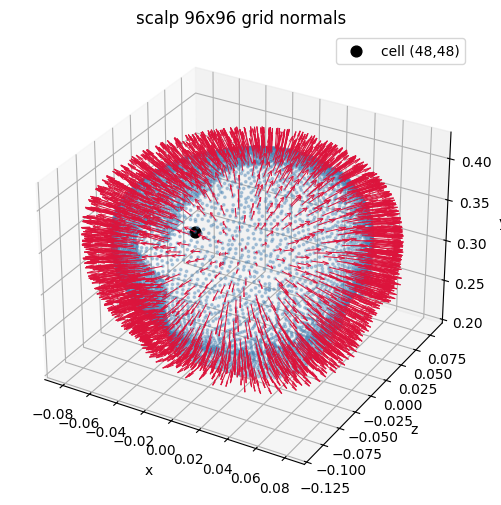

In [4]:
# 視覺化整個 grid 的法向量分布 (紅色箭頭), 黑點 = 上面查詢的 cell
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

valid_pos = grid_pos[grid_valid]
ax.scatter(valid_pos[:, 0], valid_pos[:, 2], valid_pos[:, 1], s=3, alpha=0.35, color="steelblue")

stride = 2
sv = grid_valid[::stride, ::stride]
sp = grid_pos[::stride, ::stride][sv]
sn = grid_normal[::stride, ::stride][sv]
ax.quiver(sp[:, 0], sp[:, 2], sp[:, 1], sn[:, 0], sn[:, 2], sn[:, 1], length=0.02, color="crimson", linewidth=0.7)

ax.scatter([cell_pos[0]], [cell_pos[2]], [cell_pos[1]], color="black", s=60, label=f"cell ({i},{j})")
ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_zlabel("y")
ax.set_title(f"scalp {N}x{N} grid normals")
ax.legend()
plt.show()

## 3. 讀取髮絲資料

strand_positions: (96821, 256, 3) float32
root_uv         : (96821, 2)
root_normal     : (96821, 3)


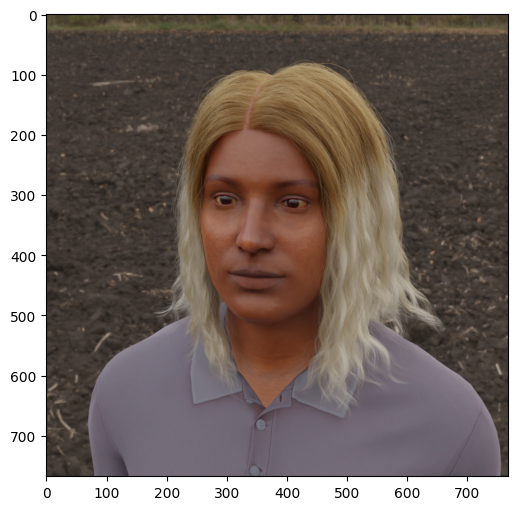

In [5]:
HAIRSTYLE_DIR = os.path.join(DATASET_ROOT, "generated_hairstyles", "base_13_idx_94847")
STRANDS_NPZ = os.path.join(HAIRSTYLE_DIR, "full_strands.npz")

strand_positions, root_uv, root_normal = load_strands(STRANDS_NPZ)
print("strand_positions:", strand_positions.shape, strand_positions.dtype)  # (S, P, 3)
print("root_uv         :", root_uv.shape)   # (S, 2)  每根髮絲髮根在頭皮 UV 上的座標
print("root_normal     :", root_normal.shape)  # (S, 3)  髮根法向量

RGB=os.path.join(HAIRSTYLE_DIR, 'rgb.png')
img = plt.imread(RGB)
plt.figure(figsize=(6, 6))
plt.imshow(img)

### 3.1 單根髮絲存取

直接用整數索引即可：`positions[k]` 拿到整條折線，`root_uv[k]` / `root_normal[k]` 是它的髮根資訊。

In [6]:
k = 12345
strand_k = strand_positions[k]  # (P, 3): 這根髮絲所有取樣點 (P=256)

print(f"strand[{k}].shape = {strand_k.shape}")
print("  髮根 (第0點):", strand_k[0])
print("  髮尾 (末點) :", strand_k[-1])
print("  root_uv     :", root_uv[k])
print("  root_normal :", root_normal[k])

seg_len = np.linalg.norm(np.diff(strand_k, axis=0), axis=1).sum()
print(f"  髮絲長度 (折線段長度加總) ≈ {seg_len:.4f}")

strand[12345].shape = (256, 3)
  髮根 (第0點): [-0.07470686  0.33914936  0.0088485 ]
  髮尾 (末點) : [-0.0667513   0.19599423 -0.00467904]
  root_uv     : [0.8259088  0.63214713]
  root_normal : [0.970308   0.06207009 0.23377272]
  髮絲長度 (折線段長度加總) ≈ 0.1575


### 3.2 一批髮絲（髮束）：拿 grid cell 的位置 + 法向量，找出「這一格正上方」的髮絲

資料本身沒有內建的髮束/群組 id，所以用第 2 節拿到的 `cell_pos` / `cell_normal` 建立一個沿法向量延伸的局部柱體，
測試每根髮絲的取樣點是否落在柱體內（`strands_above_cell`），藉此把「頭皮某一格」跟「它上面的一撮頭髮」連結起來。

In [7]:
t1, t2 = tangent_frame(cell_normal)               # 該 cell 的切線方向 (與法向量共同組成局部座標系)
half_size = estimate_half_size(grid_pos, grid_valid)  # 柱體的橫截面半徑 (預設用 grid 間距估計)

strand_mask, point_mask, local_h = strands_above_cell(
    strand_positions, cell_pos, cell_normal, t1, t2,
    half_size=half_size, h_min=-0.01, h_max=0.4,
)
bundle_idx = np.where(strand_mask)[0]
bundle = strand_positions[bundle_idx]  # (K, P, 3): 這一整束髮絲

print(f"grid cell ({i}, {j}) 上方共有 {bundle_idx.size} 根髮絲")
print("前 10 個 strand index:", bundle_idx[:10])
print("bundle.shape =", bundle.shape)

grid cell (48, 48) 上方共有 64 根髮絲
前 10 個 strand index: [ 2695 14402 14404 14407 14408 14417 14419 14427 14430 14431]
bundle.shape = (64, 256, 3)


## 5. 自訂 n×n Mask Matrix，直接轉成逐髮絲 (per-strand) mask

延續第 1 節「頭皮 UV → n×n grid」的做法，一樣手動自訂一個 n×n 的 boolean 矩陣（每一格 `False` = base color、`True` = highlight color），
鋪在頭皮 UV 空間上；但這次不是把矩陣存成「grid template」讓 Blender 在渲染時逐格查表（`coloring_by_grid`
的做法），而是**在 notebook 這裡就把每一根髮絲的 mask 算好**，變成 `highlighted` / `highlight_color`
這兩個逐髮絲 (per-strand) 的 array —— 跟 `coloring_by_strand/generate_highlight_templates_by_strand.py`
產生的 template 是同一種資料格式。

UV → grid 的 row/col 換算直接呼叫 `scalp_uv_grid.py` 的 `build_uv_bin_edges` / `uv_to_grid_rowcol` /
`grid_cell_centers_rowcol`，跟 `coloring_by_strand` pipeline 用的是同一套慣例（row 0 = UV 高 v 端，
跟其他 template PNG / `scalp_grid_rgb.jpg` 一致），不再像舊版那樣自己用 `searchsorted` 土法煉鋼。

In [8]:
from highlighting.generate_from_3D_models.scalp_uv_grid import (
    build_uv_bin_edges, grid_cell_centers_rowcol, load_scalp_uv, uv_to_grid_rowcol,
)

DATASET_PATH = DATASET_ROOT  # generate_from_3D_models pipeline 慣用的名稱 (含 generated_hairstyles/, body_data/)

scalp_uv = load_scalp_uv(DATASET_PATH)
us, vs = build_uv_bin_edges(scalp_uv, N)

row_idx, col_idx = uv_to_grid_rowcol(root_uv, us, vs)


strands_mask_grid = strands_above_cells_gpu(
    strand_positions, grid_pos, grid_normal, half_size,
    h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
)



100%|██████████| 409/409 [00:53<00:00,  7.58it/s]


## 勾邊測試

100%|██████████| 9216/9216 [00:10<00:00, 888.03it/s] 

average grid score = 0.30574286



/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22580 (\N{CJK UNIFIED IDEOGRAPH-5834}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from fo

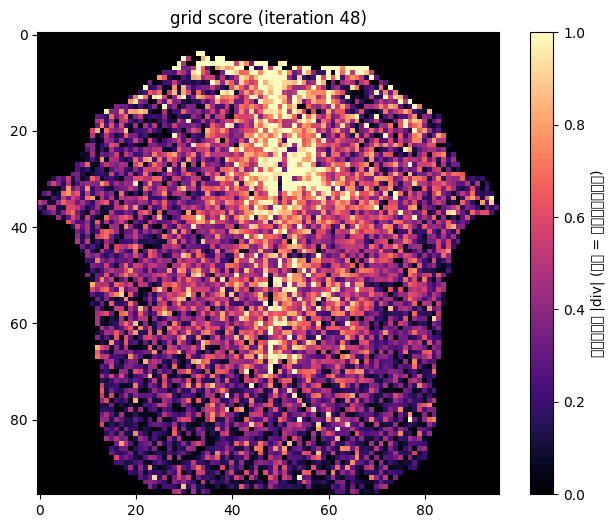

/home/kyh/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22580 (\N{CJK UNIFIED IDEOGRAPH-5834}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/kyh/.local/lib/python3.10/site-packages/IPython/c

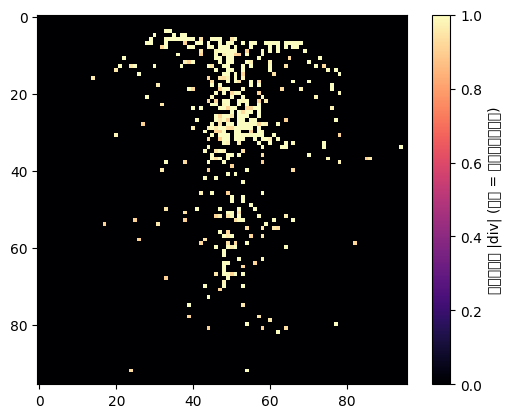

In [9]:
from tqdm import tqdm
from evaluation import project_strands_batch


def build_grid_aligned_tangent(grid_pos, grid_normal, grid_valid):
    """幫每個 grid cell 各自算一組跟「這個 n x n UV grid 本身」對齊的切線基底 (t1, t2)，
    取代 scalp_grid.tangent_frame() 那種只保證垂直於法向量、但方向在世界座標系裡是任意選的
    基底 (相鄰 cell 之間沒有連續性，2D 投影出來的 local_x/local_y 沒辦法跨格比較，疊在 2D
    圖上時箭頭方向也對不齊 grid 本身的排列)。

    做法：t1 用 grid_pos 沿 u_idx (陣列第一維，也就是 col/u 方向) 的有限差分當作「這格往 u
    增加方向」的參考向量；t2 同理用沿 v_idx (陣列第二維) 的差分。兩者都先投影掉沿法向量的
    分量、正規化，t2 再對 t1 做 Gram-Schmidt 讓兩者保持垂直——這樣 (t1, t2, normal) 仍然是
    正交基，但 t1 對齊「往右一格 (u 增加)」的實際 3D 方向、t2 盡量對齊「往上一格 (v 增加)」
    的方向，讓每一格的局部座標系彼此連續，2D 投影出來的幾何才跟 3D 的 grid 排列吻合。

    grid_valid=False 或邊界上只有一側鄰居可用時退化成單側差分；兩側鄰居都拿不到 (頭皮邊緣)
    或差分方向退化 (跟法向量幾乎平行) 時，fallback 回原本方向任意的 tangent_frame(normal)。
    """
    n_rows, n_cols = grid_valid.shape  # 陣列本身的 (u_idx, v_idx) 維度，不是顯示用的 row/col
    fb_t1_all, fb_t2_all = tangent_frame(grid_normal)  # 先整批算好 fallback 用的任意切線基底

    t1_grid = np.zeros_like(grid_pos)
    t2_grid = np.zeros_like(grid_pos)

    for u_idx in range(n_rows):
        for v_idx in range(n_cols):
            if not grid_valid[u_idx, v_idx]:
                continue
            normal = grid_normal[u_idx, v_idx]
            pos_c = grid_pos[u_idx, v_idx]

            u_prev_ok = u_idx > 0 and grid_valid[u_idx - 1, v_idx]
            u_next_ok = u_idx < n_rows - 1 and grid_valid[u_idx + 1, v_idx]
            if u_prev_ok and u_next_ok:
                du = grid_pos[u_idx + 1, v_idx] - grid_pos[u_idx - 1, v_idx]
            elif u_next_ok:
                du = grid_pos[u_idx + 1, v_idx] - pos_c
            elif u_prev_ok:
                du = pos_c - grid_pos[u_idx - 1, v_idx]
            else:
                du = None

            v_prev_ok = v_idx > 0 and grid_valid[u_idx, v_idx - 1]
            v_next_ok = v_idx < n_cols - 1 and grid_valid[u_idx, v_idx + 1]
            if v_prev_ok and v_next_ok:
                dv = grid_pos[u_idx, v_idx + 1] - grid_pos[u_idx, v_idx - 1]
            elif v_next_ok:
                dv = grid_pos[u_idx, v_idx + 1] - pos_c
            elif v_prev_ok:
                dv = pos_c - grid_pos[u_idx, v_idx - 1]
            else:
                dv = None

            t1 = t2 = None
            if du is not None:
                du_t = du - np.dot(du, normal) * normal
                du_norm = np.linalg.norm(du_t)
                if du_norm > 1e-9:
                    t1 = du_t / du_norm

            if t1 is not None and dv is not None:
                dv_t = dv - np.dot(dv, normal) * normal
                dv_orth = dv_t - np.dot(dv_t, t1) * t1  # Gram-Schmidt，讓 t2 垂直於 t1
                dv_norm = np.linalg.norm(dv_orth)
                if dv_norm > 1e-9:
                    t2 = dv_orth / dv_norm

            if t1 is None or t2 is None:
                t1, t2 = fb_t1_all[u_idx, v_idx], fb_t2_all[u_idx, v_idx]

            t1_grid[u_idx, v_idx] = t1
            t2_grid[u_idx, v_idx] = t2

    return t1_grid, t2_grid


def edge_detect_score(strands_inside, strand_positions, pos, normal, t1, t2, half_size, is_c1_mask):
    """把「c1/c2 segment 交點密度」改寫成「(局部) 向量場散度」:

    - 每根髮絲的流向 (start -> end) 依 is_c1_mask 乘上 +1 (c1) / -1 (c2) 的正負號——等同把
      「頭皮這一小塊局部空間」視為一個由髮絲流向定義的向量場，c1、c2 兩類頭髮的流向彼此反號。
    - 用這些取樣點對整個向量場做線性 (affine) 最小平方擬合: vx(x,y) ~ a0 + a1 x + a2 y,
      vy(x,y) ~ b0 + b1 x + b2 y，divergence = ∂vx/∂x + ∂vy/∂y = a1 + b2，就是這格的邊緣分數。
    - 若這一格裡 c1、c2 兩類髮絲方向大致一致 (沒有邊界穿過)，兩種正負號的向量會互相抵消，
      場近似均勻 -> 散度趨近 0；若兩類髮絲在此交錯 (顏色邊界剛好穿過這格)，正負向量在局部
      劇烈變化 -> 散度絕對值變大，取代原本的「線段交點密度」。

    t1, t2 由 build_grid_aligned_tangent 產生、跟這格在 UV grid 上「往 u / 往 v 增加」的實際
    3D 方向對齊 (不再是 scalp_grid.tangent_frame(normal) 那種方向任意的基底)，所以不同 grid
    cell 的 local_x/local_y 對應到一致的方向，2D 投影出來的幾何才跟 3D 的 grid 排列吻合。
    """
    strands_inside = np.asarray(strands_inside)
    if strands_inside.size == 0:
        return 0.0

    batch = strand_positions[strands_inside]  # (K, P, 3)
    mask, local_x, local_y = project_strands_batch(batch, pos, t1, t2, normal, half_size)

    has_valid = mask.any(axis=1)
    if has_valid.sum() < 3:  # 至少要 3 個取樣點才解得出線性場的 (a1, a2, b1, b2) 係數
        return 0.0

    first_idx = mask.argmax(axis=1)
    last_idx = mask.shape[1] - 1 - mask[:, ::-1].argmax(axis=1)
    rows = np.arange(strands_inside.shape[0])
    starts = np.stack([local_x[rows, first_idx], local_y[rows, first_idx]], axis=1)  # (K, 2)
    ends = np.stack([local_x[rows, last_idx], local_y[rows, last_idx]], axis=1)      # (K, 2)

    sample_pts = (starts + ends) * 0.5          # 向量場的取樣位置: 每根髮絲的中點
    directions = ends - starts                  # 每根髮絲的流向 (未正規化)
    # directions = directions / (np.linalg.norm(directions, axis=1, keepdims=True) + 1e-9)

    # sign = np.where(is_c1_mask[strands_inside], 1.0, -1.0)  # c1 / c2 反向 -> 邊界處場不連續
    # vectors = directions * sign[:, None]

    vectors = directions  # 這裡不再用 is_c1_mask，因為我們要計算「整個向量場的散度」，而不是只看 c1/c2 的交點密度

    pts = sample_pts[has_valid]
    vecs = vectors[has_valid]

    # 對整批取樣點做線性向量場擬合，取代逐 segment 交點測試
    design = np.column_stack([np.ones(pts.shape[0]), pts[:, 0], pts[:, 1]])  # (M, 3)
    coeff_x, *_ = np.linalg.lstsq(design, vecs[:, 0], rcond=None)
    coeff_y, *_ = np.linalg.lstsq(design, vecs[:, 1], rcond=None)

    divergence = coeff_x[1] + coeff_y[2]  # ∂vx/∂x + ∂vy/∂y
    return float(abs(divergence))




def cal_grid_edge_score(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_mask, half_size, base_color,
    strand_mask_grid = None
):
    n_rows, n_cols = grid_valid.shape

    if strand_mask_grid is None:
        strand_mask_grid = strands_above_cells_gpu(
            strand_positions, grid_pos, grid_normal, half_size,
            h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
        )
    grid_t1, grid_t2 = build_grid_aligned_tangent(grid_pos, grid_normal, grid_valid)  # 跟 grid 對齊的切線基底，整個 grid 只算一次

    grid_score = np.zeros((n_rows, n_cols), dtype=np.float32)  # (N, N) 每格的邊緣分數 (越大 = 顏色邊界越明顯)
    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        row, col = (n_cols - 1) - v_idx, u_idx  # (u_idx, v_idx) -> (row, col)，見上面說明

        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        grid_score[row, col] = edge_detect_score(
            strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx],
            grid_t1[u_idx, v_idx], grid_t2[u_idx, v_idx], half_size, None
        )
    return grid_score


plt.figure(figsize=(8, 6 ))

grid_score = cal_grid_edge_score(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, None, half_size, None,
    strand_mask_grid=strands_mask_grid
)

print("average grid score =", grid_score.mean())

# plt.subplot(2, (n_iter+1)//2+1, i+1)

plt.imshow(grid_score, origin="upper", cmap="magma", vmin=0, vmax=1)
plt.colorbar(label="向量場散度 |div| (越大 = 顏色邊界越明顯)")
plt.title(f"grid score (iteration {i})")

plt.show()

threshold = 0.9

grid_score_mask = grid_score < threshold
grid_score[grid_score_mask] = 0.0


plt.imshow(grid_score, origin="upper", cmap="magma", vmin=0, vmax=1)
plt.colorbar(label="向量場散度 |div| (越大 = 顏色邊界越明顯)")

9216it [00:10, 899.34it/s] 
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26681 (\N{CJK UNIFIED IDEOG

strand_pts2d: (4525134, 2)


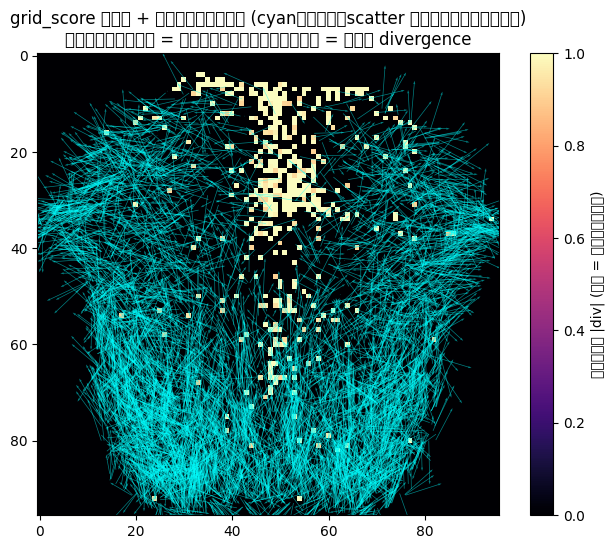

In [10]:

def cell_flow_vectors(strands_inside, strand_positions, pos, normal, t1, t2, half_size, is_c1_mask):
    """跟上面 edge_detect_score 內部同一套邏輯：算出這個 grid cell 裡每根髮絲的
    (取樣位置, 流向向量)，流向已依 is_c1_mask 乘上 +1 (c1) / -1 (c2) 的正負號，
    確保這裡視覺化的場跟拿去算 divergence 的是同一個場。

    t1, t2 現在來自 build_grid_aligned_tangent (見上一個 cell)，跟 edge_detect_score 用的是
    同一套「跟 UV grid 的 u/v 方向對齊」的切線基底，取代舊版方向任意的 tangent_frame(normal)。
    """
    strands_inside = np.asarray(strands_inside)
    if strands_inside.size == 0:
        return np.zeros((0, 2)), np.zeros((0, 2))

    batch = strand_positions[strands_inside]  # (K, P, 3)
    mask, local_x, local_y = project_strands_batch(batch, pos, t1, t2, normal, half_size)

    has_valid = mask.any(axis=1)
    if not has_valid.any():
        return np.zeros((0, 2)), np.zeros((0, 2))

    first_idx = mask.argmax(axis=1)
    last_idx = mask.shape[1] - 1 - mask[:, ::-1].argmax(axis=1)
    rows = np.arange(strands_inside.shape[0])
    starts = np.stack([local_x[rows, first_idx], local_y[rows, first_idx]], axis=1)  # (K, 2)
    ends = np.stack([local_x[rows, last_idx], local_y[rows, last_idx]], axis=1)      # (K, 2)

    sample_pts = (starts + ends) * 0.5   # 每根髮絲的取樣位置 (中點)
    directions = ends - starts           # 流向 (跟 edge_detect_score 目前版本一致：不正規化)

    # sign = np.where(is_c1_mask[strands_inside], 1.0, -1.0)  # c1 / c2 反向
    # vectors = directions * sign[:, None]

    vectors = directions  # 這裡不再用 is_c1_mask，因為我們要計算「整個向量場的散度」，而不是只看 c1/c2 的交點密度

    return sample_pts[has_valid], vectors[has_valid]


def compute_grid_vector_field(
    strand_positions, grid_pos, grid_normal, grid_valid, half_size,
    strand_mask, strand_mask_grid,
):
    """對每個有效 grid cell，把 cell_flow_vectors 算出的 (取樣點, 流向向量) 取平均當作
    這一格的「代表向量」(局部 2D，除以 half_size 變成無因次尺度)，再轉回 3D world space
    (mean_x * t1 + mean_y * t2) 方便疊在頭皮上畫 quiver。

    這個平均向量的長度，正是 edge_detect_score 拿去擬合散度的同一個場的另一種讀法：
    c1/c2 兩類髮絲流向大致一致 -> 平均後箭頭長；兩類方向相反、在此交錯抵消 -> 平均後箭頭
    變短甚至消失 (代表這裡場不連續，divergence 容易偏大)。

    t1/t2 改用 build_grid_aligned_tangent 算好的、跟 grid 對齊的切線基底 (整個 grid 只算
    一次，每格重複使用，不再逐格重算 tangent_frame)。

    註: 這個函式保留在這裡供參考/其他用途，目前下面的視覺化已經改用不平均的
    compute_strand_vectors_2d，不再呼叫這支函式。"""
    n_rows, n_cols = grid_valid.shape
    is_c1_mask = ~strand_mask  # False = base color = c1
    grid_t1, grid_t2 = build_grid_aligned_tangent(grid_pos, grid_normal, grid_valid)

    grid_vec3d = np.zeros((n_rows, n_cols, 3), dtype=np.float32)
    grid_vec_mag = np.zeros((n_rows, n_cols), dtype=np.float32)

    for u_idx, v_idx in np.ndindex(n_rows, n_cols):
        if not grid_valid[u_idx, v_idx]:
            continue
        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]
        cell_pos_ij = grid_pos[u_idx, v_idx]
        cell_normal_ij = grid_normal[u_idx, v_idx]
        t1 = grid_t1[u_idx, v_idx]
        t2 = grid_t2[u_idx, v_idx]

        _, vecs = cell_flow_vectors(
            strands_inside, strand_positions, cell_pos_ij, cell_normal_ij, t1, t2, half_size, is_c1_mask
        )
        if vecs.shape[0] == 0:
            continue

        mean_vec = vecs.mean(axis=0) / half_size  # (2,) 無因次化，方便固定 quiver 顯示尺度
        grid_vec3d[u_idx, v_idx] = mean_vec[0] * t1 + mean_vec[1] * t2
        grid_vec_mag[u_idx, v_idx] = np.linalg.norm(mean_vec)

    return grid_vec3d, grid_vec_mag


def compute_strand_vectors_2d(
    strand_positions, grid_pos, grid_normal, grid_valid, half_size,
    strand_mask, base_color, strand_mask_grid,
):
    """跟 compute_grid_vector_field_2d 拿的是同一個場 (同樣呼叫 cell_flow_vectors、除以
    half_size 無因次化)，但**不**把每格內所有髮絲的向量平均成一支代表箭頭，而是保留每一根
    髮絲自己的 (取樣位置, 流向向量)，攤平成 (M, 2) / (M, 2) 兩個陣列回傳，M = 所有有效格子
    裡的髮絲總數。用來疊圖時以類似 scatter 的方式，把每一根髮絲的流向都個別畫出來，而不是
    每格只看得到一支被平均、甚至互相抵消後消失的箭頭。

    座標轉換跟 compute_grid_vector_field_2d / cal_grid_score 用同一套對應方式：
    col = u_idx (沿 u 增加方向)，row = (n_cols - 1) - v_idx (沿 v 增加方向，但 row 是反過來
    的)。cell_flow_vectors 回傳的取樣位置/向量是在 (t1, t2) 局部座標系、以格子中心為原點、
    數值大約落在 [-half_size, half_size] 內，所以：
      - 取樣位置：除以 half_size 再乘 0.5，變成「相對格子中心的偏移，最多到格子邊界」，
        加到 (col, row) 上就會落在對應格子範圍內，畫出來才會跟 grid_score 熱力圖對齊。
      - 流向向量：除以 half_size 做無因次化 (跟 3D/平均版本一致)，local_y 分量因為 row 方向
        跟 v 方向相反，要取負號，箭頭方向才會跟 row/col 排列一致。

    t1/t2 用 build_grid_aligned_tangent 算好的、跟 grid 對齊的切線基底，整個 grid 只算一次。
    """
    n_rows, n_cols = grid_valid.shape
    # is_c1_mask = ~strand_mask
    grid_t1, grid_t2 = build_grid_aligned_tangent(grid_pos, grid_normal, grid_valid)

    all_pts, all_vecs = [], []

    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols)):
        if not grid_valid[u_idx, v_idx]:
            continue
        row, col = (n_cols - 1) - v_idx, u_idx  # 跟 cal_grid_score 同一套 (u_idx, v_idx) -> (row, col)

        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]
        sample_pts, vecs = cell_flow_vectors(
            strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx],
            grid_t1[u_idx, v_idx], grid_t2[u_idx, v_idx], half_size, None,
        )
        if vecs.shape[0] == 0:
            continue

        pts_plot = np.stack([
            col + 0.5 * sample_pts[:, 0] / half_size,
            row - 0.5 * sample_pts[:, 1] / half_size,
        ], axis=1)
        vecs_plot = np.stack([
            vecs[:, 0] / half_size,
            -vecs[:, 1] / half_size,
        ], axis=1)

        all_pts.append(pts_plot)
        all_vecs.append(vecs_plot)

    if not all_pts:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0, 2), dtype=np.float32)

    return np.concatenate(all_pts, axis=0).astype(np.float32), np.concatenate(all_vecs, axis=0).astype(np.float32)


strand_pts2d, strand_vec2d = compute_strand_vectors_2d(
    strand_positions, grid_pos, grid_normal, grid_valid, half_size,
    None, None, strands_mask_grid,
)
print("strand_pts2d:", strand_pts2d.shape)  # (M, 2) M = 有效格子裡的髮絲取樣點總數 (未平均)

# 未平均的話箭頭數 = 髮絲數，全部畫出來可能太密看不清、也畫得慢，固定隨機種子做子取樣。
max_arrows = 6000
if strand_pts2d.shape[0] > max_arrows:
    rng = np.random.default_rng(0)
    pick = rng.choice(strand_pts2d.shape[0], size=max_arrows, replace=False)
    plot_pts, plot_vecs = strand_pts2d[pick], strand_vec2d[pick]
else:
    plot_pts, plot_vecs = strand_pts2d, strand_vec2d

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_score, origin="upper", cmap="magma", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="向量場散度 |div| (越大 = 顏色邊界越明顯)")

# local_x 對齊 u 增加方向 = col 增加方向；local_y 對齊 v 增加方向，但 row = (n_cols-1) - v_idx
# 是反過來的，compute_strand_vectors_2d 內部已經把位置/向量的 y 分量都處理成跟 row 方向一致，
# 這裡直接畫就好，不用再額外取負號。
ax.quiver(
    plot_pts[:, 0], plot_pts[:, 1],
    plot_vecs[:, 0], plot_vecs[:, 1],
    color="cyan", scale=20, width=0.0015, alpha=0.5,
)
ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(N - 0.5, -0.5)  # 跟 imshow(origin="upper") 同方向: row 由上往下增加
ax.set_title("grid_score 熱力圖 + 每根髮絲的流向向量 (cyan，未平均，scatter 顯示每一根取樣點與流向)\n箭頭方向一致的區域 = 流向連續；箭頭雜亂交錯的區域 = 對應高 divergence")
plt.show()

### 5.1 把每根髮絲的髮根對應到矩陣格子 -> 逐髮絲 highlighted / highlight_color

用 `scalp_uv_grid.build_uv_bin_edges` 對頭皮 mesh 的 UV bounding box 切出 `N` 個 bin
（跟 `coloring_by_strand/generate_highlight_templates_by_strand.py` 完全同一套函式，`N` 沿用第 1 節的定義），
再用 `uv_to_grid_rowcol` 把每根髮絲的 `root_uv`（第 3 節 `load_strands` 讀出的）對應到 `mask_matrix`
的 `(row, col)`，直接查表得到這根髮絲的 mask (bool)——每根髮絲一個顏色，不再是「一個 grid cell 對應一批髮絲
共用一個顏色，渲染時才查表」。

這裡示範「整顆頭都套用矩陣顏色」（`highlighted` 全開），等同於 `coloring_by_strand` pipeline 裡
`highlighted=True` 且 `highlight_start=0.0` 的效果——每根髮絲從髮根開始就是它查到的顏色。

/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32763 (\N{CJK UNIFIED IDEOGRAPH-7FFB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kyh/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35330 (\N{CJK UNIFIED IDEOGRAPH-8A02}) missing from fon

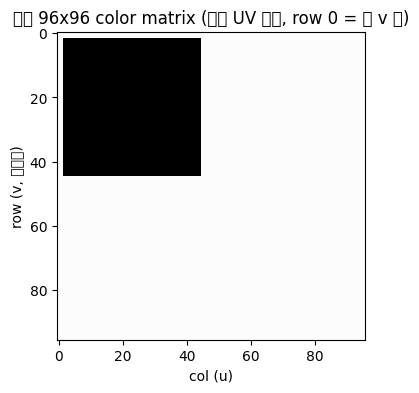

base_strand_mask.shape      = (96821,) bool
strand_highlighted.shape = (96821,)
strand 12345 落在矩陣格子 (33, 79) -> mask False


In [11]:
strand_highlighted = np.ones(root_uv.shape[0], dtype=bool)

# 每個 boolean 矩陣裡 False (0) = base_color、True (1) = highlight_color。
# 底下兩個 RGB 常數只用在「畫圖」與「存 template 給 Blender」時，把 mask 換回 RGB (mask_to_rgb)。
base_color = np.array([0.99, 0.99, 0.99])
highlight_color = np.array([0.0, 0.0, 0.0])


def mask_to_rgb(mask):
    """boolean mask (任意 shape) -> RGB float32 (shape + (3,))：False -> base_color, True -> highlight_color"""
    return np.where(np.asarray(mask, dtype=bool)[..., None], highlight_color, base_color).astype(np.float32)


mask_matrix = np.zeros((N, N), dtype=bool)  # (N, N) bool, 全 False = 全部 base_color

# 也可以改成手動逐格指定，例如只想染前兩格、其餘維持底色，取消註解試試：
# mask_matrix[5:10, 5:10] = True
# mask_matrix[5:10, -10:-5] = True
mask_matrix[2:15*3, 2:15*3] = True

show_color_matrix(mask_to_rgb(mask_matrix))


base_strand_mask = mask_matrix[row_idx, col_idx]  # (S,) bool: 每根髮絲自己的 mask，直接查表得到

print("base_strand_mask.shape      =", base_strand_mask.shape, base_strand_mask.dtype)
print("strand_highlighted.shape =", strand_highlighted.shape)
print("strand", k, "落在矩陣格子", (int(row_idx[k]), int(col_idx[k])), "-> mask", base_strand_mask[k])


In [ ]:
from tqdm import tqdm
from evaluation import *

def update_color(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_mask, half_size,
    strand_mask_grid = None,
    threshold = 0.8,
    majority_ratio_threshold = 0.9,
):
    n_rows, n_cols = grid_valid.shape

    strand_mask_iter = strand_mask.copy()  # (S,) bool 每根髮絲自己的 mask, 會在迴圈裡被改掉
    if strand_mask_grid is None:
        strand_mask_grid = strands_above_cells_gpu(
            strand_positions, grid_pos, grid_normal, half_size,
            h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
        )

    # is_c1_mask 只跟這一輪迭代開始時的 strand_mask 有關，跟 (u_idx, v_idx) 無關，
    # 提到迴圈外算一次就好 (原本 update_color 裡是每格重算一次，等價但多做了 n_rows*n_cols 次)
    is_c1_mask = ~strand_mask  # False = base color = c1

    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        if strands_inside.size == 0:
            continue

        mask_in_cell = strand_mask[strands_inside]  # (K,) bool 這一格上方的髮絲 mask
        mask_mode = int(mask_in_cell.sum()) * 2 > mask_in_cell.size  # 眾數 (True 嚴格過半才是 True，平手取 False)

        if not mask_mode:  # 如果眾數是 False (base_color)，就不用改了
            continue

        grid_score = single_grid_score2(
            strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size, is_c1_mask
        )

        if grid_score <= threshold:  # 兩類分得夠開，這一格不需要處理
            continue

        strand_mask_iter[strands_inside] = mask_mode

        # grid_score, w, split_value = single_grid_score_lda(
        #     strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size, is_c1_mask
        # )

        # if grid_score <= threshold:  # 兩類分得夠開，這一格不需要處理
        #     continue

        # is_c1_inside = is_c1_mask[strands_inside]
        # n_c1 = int(is_c1_inside.sum())
        # n_total = int(strands_inside.shape[0])
        # majority_ratio = max(n_c1, n_total - n_c1) / n_total

        # if w is None or majority_ratio >= majority_ratio_threshold:
        #     # case 1: 某一類佔絕對多數 (或樣本太少無法做 LDA) -> 直接整格染成 median
        #     strand_colors_iter[strands_inside] = color_median
        # else:
        #     # case 2: 兩類勢均力敵 -> 用 Fisher LDA 分割線把這一格分成兩側，各自染 median
        #     xy = strand_local_xy(
        #         strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size
        #     )
        #     proj = xy @ w
        #     side_a_mask = proj >= split_value
        #     side_b_mask = ~side_a_mask

        #     side_a = strands_inside[side_a_mask]
        #     side_b = strands_inside[side_b_mask]

        #     if side_a.size > 0:
        #         strand_colors_iter[side_a] = np.median(strand_colors[side_a], axis=0)
        #     if side_b.size > 0:
        #         strand_colors_iter[side_b] = np.median(strand_colors[side_b], axis=0)

    return strand_mask_iter

# def smoothness(strand_positions, grid_pos, grid_normal, grid_valid,
#     row_idx, col_idx, strand_colors, half_size, base_color,
#     strand_mask_grid = None,
#     threshold = 0.8,
#     smooth_diameter:int=5):
#     for u_idx, v_idx in tqdm(np.ndindex(grid_valid.shape), total=grid_valid.size):
#         adj_grid_idx = adjacent_grid_cells(u_idx, v_idx, grid_valid.shape, smooth_diameter)

#         for adj_u_idx, adj_v_idx in adj_grid_idx:
#             adj_color = strand_colors[strand_mask_grid[adj_u_idx, adj_v_idx]]
#             if adj_color.size == 0:
#                 continue

In [ ]:
import numpy as np
from scipy import sparse
from numba import njit
from tqdm import tqdm
from evaluation import *


# Fiduccia-Mattheyses 更新 base_coloring_state (兩種都「不建 (S, S) adjacency」，只用 cell <-> strand 的 incidence)
#   mode="clique": 每格視為一個 clique，邊權重 = 兩根髮絲共用的格數；最小化 sum_c n_true[c] * n_false[c]
#   mode="cutnet": 每格視為一條 net (hypergraph)；最小化「同時含兩種顏色的格子數」 (FM 原始論文的 cut-net 目標)

def build_cell_incidence(strand_mask_grid):
    """(n_rows, n_cols, S) bool -> 只保留含 >= 2 根髮絲的格子 (單根的格子不可能混色，對兩種目標都沒貢獻)，
    回傳 (cell_ptr, cell_members, strand_ptr, strand_cells) 兩份 CSR 索引：格子 -> 髮絲 / 髮絲 -> 格子。
    記憶體只有 O(nnz)，nnz = 所有 (格子, 髮絲) 配對數。"""
    n_rows, n_cols, n_strands = strand_mask_grid.shape
    M = sparse.csr_matrix(strand_mask_grid.reshape(n_rows * n_cols, n_strands))
    return _incidence_from_csr(M)


def _incidence_from_csr(M):
    M = M[np.diff(M.indptr) >= 2].tocsr()
    Mt = M.T.tocsr()
    return (M.indptr.astype(np.int64), M.indices.astype(np.int32),
            Mt.indptr.astype(np.int64), Mt.indices.astype(np.int32))


@njit
def _b_insert(i, key, head, nxt, prv):
    h = head[key]
    nxt[i] = h
    prv[i] = -1
    if h >= 0:
        prv[h] = i
    head[key] = i


@njit
def _b_remove(i, key, head, nxt, prv):
    p = prv[i]
    n = nxt[i]
    if p >= 0:
        nxt[p] = n
    else:
        head[key] = n
    if n >= 0:
        prv[n] = p


@njit
def _bump(u, d, gain, off, W, state, head, nxt, prv, tops):
    s = 1 if state[u] else 0  # u 還沒被鎖定，pass 期間 state[u] 不變，所以 bucket 側別固定
    _b_remove(u, s * W + gain[u] + off, head, nxt, prv)
    gain[u] += d
    key = gain[u] + off
    _b_insert(u, s * W + key, head, nxt, prv)
    if key > tops[s]:
        tops[s] = key


@njit
def _fm_pass(state, cell_ptr, cell_members, strand_ptr, strand_cells, mode, max_gain, patience, lo, hi):
    """一個 FM pass (in-place 修改 state)，回傳這個 pass 實際採用的累積 gain。
    mode 0 = clique, 1 = cutnet。gain bucket 是 (head, nxt, prv) 三個 int 陣列做成的雙向鏈結串列，
    True / False 兩側各一組 bucket (head 的前後兩半)，這樣才能在 True 的總數被限制在 [lo, hi]
    時，只從「移動後仍合法」的那一側挑最大 gain，避免整個分類塌縮成同一類。"""
    S = state.shape[0]
    R = cell_ptr.shape[0] - 1
    n1 = np.zeros(R, np.int64)  # 每格目前 True 的髮絲數
    size = np.empty(R, np.int64)
    for c in range(R):
        size[c] = cell_ptr[c + 1] - cell_ptr[c]
        for k in range(cell_ptr[c], cell_ptr[c + 1]):
            if state[cell_members[k]]:
                n1[c] += 1

    gain = np.zeros(S, np.int64)
    for v in range(S):
        g = 0
        for k in range(strand_ptr[v], strand_ptr[v + 1]):
            c = strand_cells[k]
            nF = n1[c] if state[v] else size[c] - n1[c]  # v 這一側 (含 v) 的髮絲數
            nT = size[c] - nF
            if mode == 0:
                g += nT - (nF - 1)
            else:
                if nF == 1:
                    g += 1
                if nT == 0:
                    g -= 1
        gain[v] = g

    off = max_gain
    W = 2 * max_gain + 1
    head = np.full(2 * W, -1, np.int64)
    nxt = np.empty(S, np.int64)
    prv = np.empty(S, np.int64)
    n_true = 0
    for v in range(S):
        sd = 1 if state[v] else 0
        n_true += sd
        _b_insert(v, sd * W + gain[v] + off, head, nxt, prv)

    locked = np.zeros(S, np.bool_)
    moves = np.empty(S, np.int64)
    n_moves = 0
    cum = 0
    best = 0
    best_step = 0
    tops = np.full(2, 2 * max_gain, np.int64)

    while n_moves < S:
        best_key = -1
        best_side = -1
        for sd in range(2):
            if sd == 1 and n_true - 1 < lo:  # 移動 True 側會讓 True 總數低於下限
                continue
            if sd == 0 and n_true + 1 > hi:
                continue
            while tops[sd] >= 0 and head[sd * W + tops[sd]] < 0:
                tops[sd] -= 1
            if tops[sd] > best_key:
                best_key = tops[sd]
                best_side = sd
        if best_side < 0:
            break
        v = head[best_side * W + best_key]
        _b_remove(v, best_side * W + best_key, head, nxt, prv)
        locked[v] = True
        cum += gain[v]
        moves[n_moves] = v
        n_moves += 1
        n_true += -1 if best_side == 1 else 1
        if cum > best:
            best = cum
            best_step = n_moves

        sv = state[v]
        for k in range(strand_ptr[v], strand_ptr[v + 1]):
            c = strand_cells[k]
            a = cell_ptr[c]
            b = cell_ptr[c + 1]
            nF = n1[c] if sv else size[c] - n1[c]
            nT = size[c] - nF
            if mode == 0:
                for m in range(a, b):
                    u = cell_members[m]
                    if u == v or locked[u]:
                        continue
                    _bump(u, 2 if state[u] == sv else -2, gain, off, W, state, head, nxt, prv, tops)
            else:
                if nT == 0:  # 整格都在 v 這側 -> 移動 v 會讓其他人「離開 v 這側」變成有機會消除混色
                    for m in range(a, b):
                        u = cell_members[m]
                        if u != v and not locked[u]:
                            _bump(u, 1, gain, off, W, state, head, nxt, prv, tops)
                elif nT == 1:  # 對側唯一的那根，之後移過來就不再消除混色
                    for m in range(a, b):
                        u = cell_members[m]
                        if state[u] != sv:
                            if not locked[u]:
                                _bump(u, -1, gain, off, W, state, head, nxt, prv, tops)
                            break
            if sv:
                n1[c] -= 1
            else:
                n1[c] += 1
            if mode == 1:
                nF2 = nF - 1
                if nF2 == 0:  # v 走後原本這側空了 -> 其他人 (都在對側) 移過去不再有消除混色的機會
                    for m in range(a, b):
                        u = cell_members[m]
                        if u != v and not locked[u]:
                            _bump(u, -1, gain, off, W, state, head, nxt, prv, tops)
                elif nF2 == 1:  # 原本這側只剩一根 -> 它移走就能消除混色
                    for m in range(a, b):
                        u = cell_members[m]
                        if u != v and state[u] == sv:
                            if not locked[u]:
                                _bump(u, 1, gain, off, W, state, head, nxt, prv, tops)
                            break
        state[v] = not sv

        if n_moves - best_step >= patience:  # 連續 patience 步累積 gain 沒創新高，提前結束這個 pass
            break

    for i in range(best_step, n_moves):  # 回滾沒被最佳前綴採用的移動
        state[moves[i]] = not state[moves[i]]
    return best


def fm_objectives(incidence, state):
    """回傳 (混色格數 cut-net, clique cut = sum_c n_true * n_false)。"""
    cell_ptr, cell_members, _, _ = incidence
    n1 = np.add.reduceat(state[cell_members].astype(np.int64), cell_ptr[:-1])
    size = np.diff(cell_ptr)
    return int(((n1 > 0) & (n1 < size)).sum()), int((n1 * (size - n1)).sum())


def fm_refine(incidence, state, mode="cutnet", max_passes=20, patience=None, balance_tol=0.02, verbose=True):
    """FM 迭代更新 2-way 分類 state (bool, (S,))，回傳新的 state (不改動輸入)。
    每個 pass 依 gain 由大到小把髮絲各移動一次並鎖住，只採用累積 gain 最大的前綴，重複到沒有改善。
    patience: 連續多少步累積 gain 沒創新高就提前結束該 pass；None = 不提前結束 (完整 FM)。
    balance_tol: True 的總數只能偏離初始值 balance_tol * S 以內 (預設 2%)；None = 不限制。
      cut-net 目標「全部同一類」就是 0 混色，不設限制的話會塌縮成單一顏色，所以預設要限。"""
    cell_ptr, cell_members, strand_ptr, strand_cells = incidence
    n_strands = strand_ptr.shape[0] - 1
    assert state.shape == (n_strands,)
    state = state.astype(np.bool_).copy()

    if mode == "clique":
        mode_id = 0
        entry_strand = np.repeat(np.arange(n_strands), np.diff(strand_ptr))
        max_gain = int(np.bincount(entry_strand, weights=np.diff(cell_ptr)[strand_cells] - 1,
                                   minlength=n_strands).max())
    elif mode == "cutnet":
        mode_id = 1
        max_gain = int(np.diff(strand_ptr).max())
    else:
        raise ValueError(mode)
    max_gain = max(max_gain, 1)
    if patience is None:
        patience = n_strands + 1
    n_true0 = int(state.sum())
    tol = n_strands if balance_tol is None else int(balance_tol * n_strands)
    lo, hi = max(0, n_true0 - tol), min(n_strands, n_true0 + tol)

    if verbose:
        print(f"[FM/{mode}] start: mixed cells = {fm_objectives(incidence, state)[0]}, "
              f"clique cut = {fm_objectives(incidence, state)[1]}")
    for pass_idx in tqdm(range(max_passes)):
        gained = _fm_pass(state, cell_ptr, cell_members, strand_ptr, strand_cells,
                          mode_id, max_gain, patience, lo, hi)
        if verbose:
            print(f"[FM/{mode}] pass {pass_idx}: gain = {gained}, "
                  f"mixed cells = {fm_objectives(incidence, state)[0]}, "
                  f"clique cut = {fm_objectives(incidence, state)[1]}")
        if gained <= 0:
            break
    return state


incidence = build_cell_incidence(strands_mask_grid)
print("cells (>=2 strands):", incidence[0].shape[0] - 1, " incidence nnz:", incidence[1].shape[0])

# True = highlight (cell 19 塗色的 highlight 區塊)，False = base_color。mask 本身就是 bool，直接用。
base_coloring_state_init = base_strand_mask.copy()

state_clique = fm_refine(incidence, base_coloring_state_init, mode="clique")
state_cutnet = fm_refine(incidence, base_coloring_state_init, mode="cutnet")

base_coloring_state = state_cutnet  # 預設採用 cut-net 版本 (目標 = 每格顏色一致)
for name, st in [("init", base_coloring_state_init), ("clique", state_clique), ("cutnet", state_cutnet)]:
    print(f"{name:7s} True = {int(st.sum())}, False = {int((~st).sum())}, "
          f"changed vs init = {int((st != base_coloring_state_init).sum())}, "
          f"(mixed cells, clique cut) = {fm_objectives(incidence, st)}")

iter_strand_masks = [base_coloring_state_init, state_clique, state_cutnet]

In [ ]:
n_iter = 3

iter_strand_masks = [ base_strand_mask.copy() ]  # 每個元素 (S,) bool

for _ in range(n_iter):
    m_strand_mask = update_color(
        strand_positions, grid_pos, grid_normal, grid_valid,
        row_idx, col_idx, iter_strand_masks[-1], half_size,
        strand_mask_grid=strands_mask_grid,
        threshold=0.1
    )
    iter_strand_masks.append(m_strand_mask)

In [ ]:
# 以髮根 UV 座標繪製髮絲顏色的 2D 點雲分布
# 每個點代表一根髮絲，顏色由 strand mask 經 mask_to_rgb 換算
n_plots = len(iter_strand_masks)
fig, axes = plt.subplots(n_plots, 1, figsize=(16, 4 * n_plots))
fig.set_facecolor("#1e1e1e")
for ax in axes:
    ax.set_facecolor("gray")    # 繪圖區域的底色（scatter/imshow 底下那層）

for i, strand_mask in enumerate(iter_strand_masks):
    draw_strand_uv_color_distribution(root_uv, mask_to_rgb(strand_mask), ax=axes[i], show=False)

plt.show()


In [ ]:
from tqdm import tqdm
from scipy.spatial import ConvexHull
def cal_grid_score(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_mask, half_size,
    strand_mask_grid = None
):
    n_rows, n_cols = grid_valid.shape

    if strand_mask_grid is None:
        strand_mask_grid = strands_above_cells_gpu(
            strand_positions, grid_pos, grid_normal, half_size,
            h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
        )
    is_c1_mask = ~strand_mask  # False = base color = c1

    grid_score = np.zeros((n_rows, n_cols), dtype=np.float32)  # (N, N) 每格的髮絲顏色熵值 (越大 = 顏色越分散)
    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        row, col = (n_cols - 1) - v_idx, u_idx  # (u_idx, v_idx) -> (row, col)，見上面說明

        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        grid_score[row, col] = single_grid_score2(
            strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size, is_c1_mask
        )
    return grid_score
for ax in axes:
    ax.set_facecolor("gray")    # 繪圖區域的底色（scatter/imshow 底下那層）

for i in range(n_iter+1):
    print(f"=== iteration {i} ===")
    grid_score = cal_grid_score(
        strand_positions, grid_pos, grid_normal, grid_valid,
        row_idx, col_idx, iter_strand_masks[i], half_size,
        strand_mask_grid=strands_mask_grid
    )

    grid_score[grid_score < 0.99] = 0.0

    print("average grid score =", grid_score.mean())

    if(i):
        changed = iter_strand_masks[i] != iter_strand_masks[i-1]
        print(changed.shape)
        print("diff:", changed.mean())  # 這一輪被翻轉的髮絲比例

    plt.subplot(2, (n_iter+1)//2+1, i+1)

    plt.imshow(grid_score, origin="upper", cmap="magma", vmin=0, vmax=1)
    plt.colorbar(label="交點密度 (越大 =  顏色越分散)")
    plt.title(f"grid score (iteration {i})")

plt.show()

### 2D rendering result

In [ ]:
from tqdm import tqdm
from scipy.spatial import ConvexHull

def cal_2d_grid_color(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_mask, half_size,
    strand_mask_grid
):
    n_rows, n_cols = grid_valid.shape

    # if strand_mask_grid is None:
    #     strand_mask_grid = strands_above_cells_gpu(
    #         strand_positions, grid_pos, grid_normal, half_size,
    #         h_min=-0.01, h_max=0.4, grid_valid=grid_valid, show_progress=True,
    #     )

    grid_mask = np.zeros((n_rows, n_cols), dtype=bool)  # (N, N) bool 每格的 mask 眾數
    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        row, col = (n_cols - 1) - v_idx, u_idx  # (u_idx, v_idx) -> (row, col)，見上面說明

        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        # grid_score[row, col] = single_grid_score2(
        m = strand_mask[strands_inside]
        grid_mask[row, col] = m.sum() * 2 > m.size  # bool 的 median = 眾數 (平手 / 空格取 False)
        #     strands_inside, strand_positions, grid_pos[u_idx, v_idx], grid_normal[u_idx, v_idx], half_size, is_c1_mask
        # )
    return grid_mask


plt.figure(figsize=(6*(n_iter+1), 12 ))

for i in range(n_iter+1):
    print(f"=== iteration {i} ===")
    grid_mask_i = cal_2d_grid_color(
        strand_positions, grid_pos, grid_normal, grid_valid,
        row_idx, col_idx, iter_strand_masks[i], half_size,
        strand_mask_grid=strands_mask_grid
    )

    print(grid_mask_i.shape, grid_mask_i.dtype)

    plt.subplot(2, (n_iter+1)//2+1, i+1)

    plt.imshow(mask_to_rgb(grid_mask_i))
    # plt.imshow(grid_mask_i, origin="upper", cmap="magma", vmin=0, vmax=1)
    # plt.colorbar(label="交點密度 (越大 =  顏色越分散)")
    plt.title(f"grid mask (iteration {i})")

plt.show()

In [ ]:
## analyze result

show_direction_vec = True
show_edge_detect_score = False

from tqdm import tqdm
from scipy.spatial import ConvexHull

def cal_2d_grid_color(
    strand_positions, grid_pos, grid_normal, grid_valid,
    row_idx, col_idx, strand_mask, half_size,
    strand_mask_grid
):
    n_rows, n_cols = grid_valid.shape

    grid_mask = np.zeros((n_rows, n_cols), dtype=bool)  # (N, N) bool 每格的 mask 眾數
    for u_idx, v_idx in tqdm(np.ndindex(n_rows, n_cols), total=n_rows * n_cols):
        row, col = (n_cols - 1) - v_idx, u_idx  # (u_idx, v_idx) -> (row, col)，見上面說明

        strands_inside = np.where(strand_mask_grid[u_idx, v_idx])[0]  # (K,) 這一格上方的髮絲索引
        m = strand_mask[strands_inside]
        grid_mask[row, col] = m.sum() * 2 > m.size  # 眾數 (平手 / 空格取 False)
    return grid_mask


# --- show_direction_vec / show_edge_detect_score 疊圖用的縮小顯示參數 ---
# 箭頭/散度 marker 都刻意縮小 (短箭頭、細線、小點)，疊在 grid mask 上時才不會蓋住底下的顏色。
quiver_scale = 60                # quiver 的 scale 參數，越大箭頭畫出來越短
quiver_width = 0.0015            # 箭頭線寬 (縮小顯示體積)
quiver_alpha = 0.5                # 箭頭透明度：未平均後箭頭數 = 髮絲數，半透明避免疊起來糊成一片
max_arrows = 6000                # 箭頭數上限，超過就固定隨機種子做子取樣 (仍是未平均的原始向量)
score_marker_max = 14            # edge score 疊加點的最大 marker 面積 (縮小顯示體積，不畫滿整格)
score_alpha = 0.85                # edge score 疊加點的透明度，留一點底下顏色透出來

plt.figure(figsize=(8 ,8*(n_iter+1)))

for i in range(n_iter+1):
    print(f"=== iteration {i} ===")
    grid_mask_i = cal_2d_grid_color(
        strand_positions, grid_pos, grid_normal, grid_valid,
        row_idx, col_idx, iter_strand_masks[i], half_size,
        strand_mask_grid=strands_mask_grid
    )

    ax = plt.subplot(n_iter+1, 1, i+1)

    ax.set_facecolor("gray")  # 繪圖區域的底色（scatter/imshow 底下那層）
    ax.imshow(mask_to_rgb(grid_mask_i))

    if show_direction_vec:
        # 跟前面「每根髮絲的向量」同一套場 (cell_flow_vectors / compute_strand_vectors_2d)，
        # 不做 grid 內平均，保留每根髮絲自己的取樣點與流向；箭頭故意縮小、半透明、並隨機
        # 子取樣，避免整張圖被箭頭蓋住看不到底下的髮色。
        strand_pts2d_i, strand_vec2d_i = compute_strand_vectors_2d(
            strand_positions, grid_pos, grid_normal, grid_valid, half_size,
            iter_strand_masks[i], base_color, strands_mask_grid,
        )
        if strand_pts2d_i.shape[0] > max_arrows:
            rng = np.random.default_rng(i)
            pick = rng.choice(strand_pts2d_i.shape[0], size=max_arrows, replace=False)
            strand_pts2d_i, strand_vec2d_i = strand_pts2d_i[pick], strand_vec2d_i[pick]
        ax.quiver(
            strand_pts2d_i[:, 0], strand_pts2d_i[:, 1],
            strand_vec2d_i[:, 0], strand_vec2d_i[:, 1],
            color="cyan", scale=quiver_scale, width=quiver_width, alpha=quiver_alpha,
        )

    if show_edge_detect_score:
        # 跟「勾邊測試」同一套 edge_detect_score (向量場散度)，用小 marker 疊加而不是整格塗滿色塊；
            # marker 面積/透明度都跟著分數走，分數趨近 0 的格子幾乎看不到 marker，不會蓋住底色。
        grid_score_i = cal_grid_edge_score(
            strand_positions, grid_pos, grid_normal, grid_valid,
            row_idx, col_idx, iter_strand_masks[i], half_size, base_color,
            strand_mask_grid=strands_mask_grid
        )
        score_row_idx, score_col_idx = np.nonzero(grid_score_i > 1e-3)
        score_vals = np.clip(grid_score_i[score_row_idx, score_col_idx], 0, 1)
        ax.scatter(
            score_col_idx, score_row_idx,
            # marker 面積 (scatter 的 s) 跟半徑的平方成正比，所以要讓「半徑」隨分數線性縮小、
            # 最大分數時維持 score_marker_max 這個大小，s 要跟 score_vals**2 成正比 (而不是 score_vals)：
            # s = score_marker_max 時 radius = R_max；score_vals 變成一半時 radius 也變成一半，
            # 對應的 s (= π r^2) 就要變成 1/4，也就是 score_vals**2 的縮放。
            s=(score_vals ** 2) * score_marker_max, c=score_vals,
            cmap="magma", vmin=0, vmax=1, alpha=score_alpha, linewidths=0,
        )

    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)  # 跟 imshow(origin="upper") 同方向: row 由上往下增加
    ax.set_title(f"grid mask (iteration {i})")

plt.show()

In [ ]:
# =====================================================================================
# Active Contour 測試：讓 base mask (mask_matrix) 的邊界「自然吸附」到頭皮流向向量場自己的邊界
#
# 觀念 —— 髮絲流向場是頭皮本身的性質，場的不連續處 (分邊線 / 髮旋，也就是 |div v| 的山脊) 就是天然最佳的
# 顏色邊界：沿著它切，髮絲不會被切成兩色。所以不再讓 snake 自己在邊緣圖上摸索 (GVF 在稀疏山脊上捕捉範圍太短，
# 輪廓幾乎不動；為了保面積又會讓輪廓在沒有邊界的地方亂飄)，而是：
#   1. 先明確抽出向量場的「自然邊界」(|div v| 的山脊線，Hessian 山脊偵測 + 遲滯門檻 + 長度過濾，濾掉孤立的點狀峰值)
#   2. 以 base mask 的邊界為初始輪廓；輪廓上離自然邊界 <= snap_radius 的點，被「距離轉換」力場直接拉到最近的
#      自然邊界上 (Cohen 的 distance-transform 外力，捕捉範圍固定、力量與距離無關)
#   3. 離自然邊界太遠的點沒有邊界可吸，用彈簧固定在原本位置，不會亂飄 (這也是不再需要 keep_area 的原因)
# 邊界吸附的位置與形狀完全由向量場決定；base mask 只決定「哪一段輪廓要去吸」。
#
# 流程：strand_pts2d / strand_vec2d -> 稠密流向場 (vx, vy) -> |div| 邊緣圖 -> 自然邊界 -> snake -> 新 mask
# 輸出：ac_mask (N, N) bool；ac_strand_mask (S,) bool (跟 iter_strand_masks 的元素同格式，可直接餵給後面的流程)
# =====================================================================================

import cv2
from scipy import ndimage as ndi
from scipy.spatial import cKDTree
from matplotlib.path import Path


# ---------- 1. 髮絲流向向量 (strand_pts2d / strand_vec2d) -> 稠密 (N, N) 向量場 -> 邊緣圖 ----------
def rasterize_flow_field(pts2d, vec2d, n, sigma=1.0, min_count=1.0):
    """把「勾邊測試」算出的逐髮絲 (取樣位置, 流向向量) 點雲，用 normalized convolution 鋪成 (n, n) 稠密向量場。

    pts2d 已經是 (col, row) 圖像座標 (格子 (row, col) 的中心 = 整數座標)，vec2d 的 y 分量也已對齊 row 方向。
    向量先正規化成單位方向 (只看流向、不受髮絲投影長度影響)，再累加進所在格子，最後對「向量總和」與「髮絲數」
    各做一次 Gaussian 平滑後相除 = 局部平均流向。局部方向雜亂 / 相反的地方平均後長度 < 1，
    完全沒有髮絲的地方 (count 太低) 設為 0。回傳 vx, vy (皆為 (n, n))，x = col 方向, y = row 方向。
    """
    unit = vec2d / (np.linalg.norm(vec2d, axis=1, keepdims=True) + 1e-9)
    col = np.clip(np.rint(pts2d[:, 0]).astype(int), 0, n - 1)
    row = np.clip(np.rint(pts2d[:, 1]).astype(int), 0, n - 1)

    sum_x, sum_y, count = (np.zeros((n, n), np.float64) for _ in range(3))
    np.add.at(sum_x, (row, col), unit[:, 0])
    np.add.at(sum_y, (row, col), unit[:, 1])
    np.add.at(count, (row, col), 1.0)

    cnt_s = ndi.gaussian_filter(count, sigma)
    ok = cnt_s > min_count * 1e-3 * count.sum() / (n * n)  # 相對於平均密度的極小門檻: 只排除真正沒髮絲的格子
    vx = np.where(ok, ndi.gaussian_filter(sum_x, sigma) / np.maximum(cnt_s, 1e-9), 0.0)
    vy = np.where(ok, ndi.gaussian_filter(sum_y, sigma) / np.maximum(cnt_s, 1e-9), 0.0)
    return vx, vy, ok


def flow_edge_map(vx, vy, valid, smooth=1.0, pct=98):
    """邊緣圖 f = |div v| (跟「勾邊測試」把向量場散度當成顏色邊界訊號同一套想法)，
    在頭皮有效範圍內用第 pct 百分位正規化到 [0, 1]。"""
    div = np.gradient(vx, axis=1) + np.gradient(vy, axis=0)  # ∂vx/∂col + ∂vy/∂row
    f = ndi.gaussian_filter(np.abs(div), smooth)
    f[~valid] = 0.0
    return np.clip(f / (np.percentile(f[valid], pct) + 1e-9), 0, 1)


# ---------- 2. 抽出向量場的「自然邊界」: |div v| 的山脊線 ----------
def extract_natural_boundary(edge, valid, sigma=1.0, t_low=0.5, t_high=0.85, min_extent=15):
    """Steger 式山脊偵測: 用 Hessian 最負特徵值的方向當「跨山脊方向」，沿該方向做非極大值抑制，
    只留山脊中心線；再做遲滯門檻 + 長度過濾:
      * 連通元件內至少要有一點 edge >= t_high (真的很強的邊界)，元件裡其餘點 edge >= t_low 即可跟著保留
      * 元件的外接框最長邊 >= min_extent (cell)，濾掉孤立的點狀峰值 (髮旋中心之類的局部高散度，不是一條線)
    回傳 (n, n) bool 自然邊界 mask。"""
    hyy = ndi.gaussian_filter(edge, sigma, order=(2, 0))
    hxx = ndi.gaussian_filter(edge, sigma, order=(0, 2))
    hxy = ndi.gaussian_filter(edge, sigma, order=(1, 1))
    tr, det = hxx + hyy, hxx * hyy - hxy ** 2
    lam = tr / 2 - np.sqrt(np.maximum(tr ** 2 / 4 - det, 0))  # 最負特徵值 = 跨山脊方向的曲率
    nx, ny = hxy, lam - hxx                                   # 對應的特徵向量 (x = col, y = row)
    norm = np.hypot(nx, ny)
    bad = norm < 1e-9
    nx = np.where(bad, 1.0, nx / np.where(bad, 1, norm))
    ny = np.where(bad, 0.0, ny / np.where(bad, 1, norm))

    rr, cc = np.mgrid[0:edge.shape[0], 0:edge.shape[1]].astype(float)
    f_p = ndi.map_coordinates(edge, [rr + ny, cc + nx], order=1, mode="nearest")
    f_m = ndi.map_coordinates(edge, [rr - ny, cc - nx], order=1, mode="nearest")
    ridge = (edge >= f_p) & (edge >= f_m) & (lam < 0) & (edge > t_low) & valid

    lab, n_lab = ndi.label(ridge, structure=np.ones((3, 3)))
    keep = np.zeros(n_lab + 1, dtype=bool)
    for i, sl in enumerate(ndi.find_objects(lab), start=1):
        comp = lab[sl] == i
        extent = max(sl[0].stop - sl[0].start, sl[1].stop - sl[1].start)
        keep[i] = extent >= min_extent and edge[sl][comp].max() >= t_high
    return keep[lab]


def boundary_snap_field(boundary, snap_radius):
    """距離轉換外力: 每個位置指向「最近的自然邊界點」的位移向量 (dx, dy)，以及吸附權重 w。
    距離 <= snap_radius 時 w = 1 (完全吸附)，之後線性降到 2 * snap_radius 處 w = 0 (不再吸附)。
    沒有任何自然邊界時 w 全為 0 (輪廓保持不動)。"""
    n_rows, n_cols = boundary.shape
    if not boundary.any():
        z = np.zeros(boundary.shape)
        return z, z, z
    dist, (near_r, near_c) = ndi.distance_transform_edt(~boundary, return_indices=True)
    rr, cc = np.mgrid[0:n_rows, 0:n_cols]
    w = np.clip(2.0 - dist / snap_radius, 0.0, 1.0)
    return (near_c - cc).astype(float), (near_r - rr).astype(float), w


# ---------- 3. Snake (Kass et al.) : 以 base mask 的邊界為初始 contour ----------
def _resample_closed(pts, spacing=1.0):
    seg = np.linalg.norm(np.roll(pts, -1, axis=0) - pts, axis=1)
    total = seg.sum()
    m = max(int(round(total / spacing)), 8)
    s = np.concatenate([[0], np.cumsum(seg)])
    t = np.linspace(0, total, m, endpoint=False)
    closed = np.vstack([pts, pts[:1]])
    return np.stack([np.interp(t, s, closed[:, 0]), np.interp(t, s, closed[:, 1])], axis=1)


def _polygon_area(p):  # 帶正負號 (shoelace)
    x, y = p[:, 0], p[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def _snake_matrix_inv(m, alpha, beta, gamma):
    """(A + gamma I)^-1，A = beta * D4 - alpha * D2 (closed 環狀差分)，pentadiagonal cyclic。"""
    a = np.zeros((m, m))
    idx = np.arange(m)
    a[idx, idx] = 2 * alpha + 6 * beta + gamma
    for k, w in ((1, -(alpha + 4 * beta)), (2, beta)):
        a[idx, (idx + k) % m] += w
        a[idx, (idx - k) % m] += w
    return np.linalg.inv(a)


def boundary_snake(contour, snap_dx, snap_dy, snap_w, alpha=0.2, beta=0.4, gamma=1.0, kappa=1.0,
                   anchor=0.5, n_iter=100, resample_every=5, bounds=None):
    """單一封閉 contour (m, 2)，座標 (x=col, y=row)。每個點受兩種外力 (都是「位移」，單位 cell):
      * 吸附力 kappa * w * (最近自然邊界點 - 目前位置): 在 snap_radius 內把點拉上自然邊界；kappa = 1 = 一步到位
      * 錨定力 anchor * (1 - w) * (初始輪廓上最近的點 - 目前位置): 沒有邊界可吸的地方，別讓 snake 亂飄
    內部能量 (alpha 彈性 / beta 剛性) 讓吸附後的輪廓保持平滑，吸附段與沒吸附的段之間也靠它順接。"""
    pts = _resample_closed(contour)
    tree = cKDTree(_resample_closed(contour, spacing=0.25))
    dense = tree.data
    ainv, ainv_m = None, -1
    for it in range(n_iter):
        if it % resample_every == 0:
            pts = _resample_closed(pts)
        m = pts.shape[0]
        if m != ainv_m:
            ainv, ainv_m = _snake_matrix_inv(m, alpha, beta, gamma), m
        q = [pts[:, 1], pts[:, 0]]
        sample = lambda a: ndi.map_coordinates(a, q, order=1, mode="nearest")
        w = sample(snap_w)
        snap = np.stack([sample(snap_dx), sample(snap_dy)], axis=1) * w[:, None]
        _, j = tree.query(pts)
        hold = (dense[j] - pts) * (anchor * (1 - w))[:, None]
        pts = ainv @ (gamma * pts + kappa * snap + hold)
        if bounds is not None:
            pts[:, 0] = np.clip(pts[:, 0], -0.5, bounds[1] - 0.5)
            pts[:, 1] = np.clip(pts[:, 1], -0.5, bounds[0] - 0.5)
    return pts


# ---------- 4. 對 base mask 跑 active contour ----------
def mask_to_contours(mask, up=4):
    """boolean (n, n) mask -> 封閉輪廓列表 (每個 (m, 2), 座標 x=col, y=row，單位=cell)。
    先把 mask 放大 up 倍再取輪廓 (輪廓落在放大後像素中心，放大越多越貼近真正的格線邊界)，再換算回 cell 座標。"""
    big = np.kron(mask.astype(np.uint8), np.ones((up, up), np.uint8))
    big = np.pad(big, 1)  # 貼著邊界的 mask 也要能形成封閉輪廓
    found, _ = cv2.findContours(big, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)
    return [((c[:, 0, :].astype(np.float64) - 1 + 0.5) / up - 0.5) for c in found if len(c) >= 8]


def contours_to_mask(contours, shape):
    """封閉輪廓 -> boolean mask (cell 中心落在輪廓內即為 True)；用 even-odd (XOR) 規則，內孔自然挖空。"""
    rr, cc = np.mgrid[0:shape[0], 0:shape[1]]
    centers = np.stack([cc.ravel(), rr.ravel()], axis=1)
    out = np.zeros(shape[0] * shape[1], dtype=bool)
    for c in contours:
        out ^= Path(c).contains_points(centers)
    return out.reshape(shape)


def active_contour_mask(base_mask, snap_dx, snap_dy, snap_w, **snake_kwargs):
    """以 base_mask 的邊界為初始輪廓，吸附到自然邊界，回傳 (新 mask, 初始輪廓列表, 演化後輪廓列表)。"""
    init = mask_to_contours(base_mask)
    final = [boundary_snake(c, snap_dx, snap_dy, snap_w, bounds=base_mask.shape, **snake_kwargs) for c in init]
    return contours_to_mask(final, base_mask.shape), init, final



# ---------------------------------- 執行 ----------------------------------
flow_sigma = 1.5     # 髮絲向量鋪成稠密場時的 Gaussian 平滑 (cell)，越大流向場越平滑
edge_smooth = 1.5    # 邊緣圖 |div| 的平滑 (cell)
snap_radius = 8      # 輪廓離自然邊界多近 (cell) 才會被吸附上去；越大越容易被遠處的邊界拉走
snake_kwargs = dict(
    alpha=0.2,       # 彈性 (拉緊 contour)
    beta=0.4,        # 剛性 (抗彎曲)
    kappa=1.0,       # 吸附強度，1 = 一步到位貼上自然邊界
    anchor=0.5,      # 沒有邊界可吸的輪廓段固定在原位的強度
    n_iter=100,
)

# grid_valid 是 (u_idx, v_idx) 排列，換成跟 mask_matrix 一致的 (row, col) 排列: row = (N-1) - v_idx, col = u_idx
valid_rc = grid_valid.T[::-1, :]

flow_vx, flow_vy, flow_ok = rasterize_flow_field(strand_pts2d, strand_vec2d, N, sigma=flow_sigma)
edge_map = flow_edge_map(flow_vx, flow_vy, valid_rc & flow_ok, smooth=edge_smooth)
natural_boundary = extract_natural_boundary(edge_map, ndi.binary_erosion(valid_rc & flow_ok, iterations=3))  # 頭皮外緣會有假邊界，先內縮排除
snap_dx, snap_dy, snap_w = boundary_snap_field(natural_boundary, snap_radius)


n_iter = 3
for _ in range(n_iter):
    ac_mask, init_contours, final_contours = active_contour_mask(mask_matrix, snap_dx, snap_dy, snap_w, **snake_kwargs)
    ac_strand_mask = ac_mask[row_idx, col_idx]  # (S,) bool: 每根髮絲自己的 mask，跟 base_strand_mask 同樣的查表方式

    print("base mask 面積 :", int(mask_matrix.sum()), "cells")
    print("AC   mask 面積 :", int(ac_mask.sum()), "cells")
    print("被翻轉的 cell   :", int((ac_mask != mask_matrix).sum()), "cells")
    print("被翻轉的髮絲比例:", float((ac_strand_mask != base_strand_mask).mean()))


    # ---------------------------------- 視覺化 ----------------------------------
    def draw_contours(ax, contours, **kw):
        for c in contours:
            ax.plot(*np.vstack([c, c[:1]]).T, **kw)
    plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Droid Sans Fallback', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False


    step = 3
    gx, gy = np.meshgrid(np.arange(0, N, step), np.arange(0, N, step))
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    axes[0].imshow(np.where(valid_rc, 0.85, 0.3), cmap="gray", vmin=0, vmax=1)
    axes[0].quiver(gx, gy, flow_vx[::step, ::step], flow_vy[::step, ::step],
                color="tab:blue", angles="xy", scale_units="xy", scale=0.5, width=0.003)
    axes[0].set_title("稠密流向場 (單位向量的局部平均)")

    im = axes[1].imshow(edge_map, cmap="magma", vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[1], fraction=0.046, label="|div v| (正規化)")
    by, bx = np.nonzero(natural_boundary)
    axes[1].scatter(bx, by, s=5, c="cyan", label="自然邊界")
    draw_contours(axes[1], init_contours, color="white", ls="--", lw=1.2)
    draw_contours(axes[1], final_contours, color="lime", lw=1.8)
    axes[1].set_title("邊緣圖 + 自然邊界 (cyan)\n白虛線 = 初始輪廓，綠線 = 演化後輪廓")

    axes[2].imshow(mask_to_rgb(mask_matrix))
    draw_contours(axes[2], init_contours, color="tab:red", lw=1.2)
    axes[2].set_title("base mask")

    axes[3].imshow(mask_to_rgb(ac_mask))
    draw_contours(axes[3], final_contours, color="tab:red", lw=1.2)
    axes[3].set_title("active contour 後的 mask")

    for ax in axes:
        ax.set_xlim(-0.5, N - 0.5)
        ax.set_ylim(N - 0.5, -0.5)  # 跟 imshow(origin="upper") 同方向: row 由上往下增加
    plt.show()

    # init_contours = final_contours
    mask_matrix = ac_mask


## 6. 存成 `coloring_by_strand` 的 per-strand template 格式，並用 Blender 渲染正面照

`coloring_by_strand/generate_highlight_render_by_strand.py` 這條 pipeline 認得的 per-strand
template，就是 `generate_highlight_templates_by_strand.py` 產生的格式，一個 npz 內含：

| key | 說明 |
|---|---|
| `highlighted` | `(nr_strands,)` bool，這根髮絲要不要套用 `highlight_color` |
| `highlight_color` | `(nr_strands, 3)` float32，`[0,1]` 的 RGB — 每根髮絲自己的顏色 |
| `root_uv` | `(nr_strands, 2)` float32 — 這個 template 是針對哪個 `root_uv` 排列烤出來的，渲染時會拿來跟 `--input_npz` 自己的 `root_uv` 核對，確保沒有對錯髮型/順序 |

跟舊版 `coloring_by_grid` 的 `{mask, grid_size, rgb}` 格式不同——這裡完全不需要 n×n grid，Blender
渲染端 (`generate_highlight_render_by_strand.py`) 也不會再做任何 UV 查表，直接把 `highlighted[k]` /
`highlight_color[k]` 逐一套用到第 `k` 根髮絲上。

把第 5 節算好的 `strand_highlighted` / strand mask（用 `mask_to_rgb` 換成 RGB 的 `strand_colors`）存成這個格式（`mask` 全開的等效寫法 = 全部
`highlighted=True`，整顆頭都交給查表結果決定顏色），再直接呼叫 Blender 端的
`coloring_by_strand/generate_highlight_render_by_strand.py`（不需要也沒有 `--use_template_color`
這種 flag——per-strand template 本來就是每根髮絲都各自帶著自己的顏色），渲染一張正面照。

In [ ]:
from IPython.display import Image, display
fig, ax = plt.subplots(2,1,figsize=(6*(n_iter+1), 6))
GEN3D_DIR = os.path.join(PROJECT_ROOT, "highlighting", "generate_from_3D_models")
CODE_BY_STRAND_DIR = os.path.join(GEN3D_DIR, "coloring_by_strand")

RENDER_SCRIPT = os.path.join(CODE_BY_STRAND_DIR, "generate_highlight_render_by_strand.py")
RUN_BLENDER_SH = os.path.join(CODE_BY_STRAND_DIR, "run_highlight_render.sh")
BLENDER_PATH = "/home/kyh/blender/blender"


fig, ax = plt.subplots(2,1,figsize=(6, 6))

base_npz_path = save_template_npz(
    template_dir=os.path.join(PROJECT_ROOT, "highlighting", "generate_from_3D_models", "coloring_by_strand", "base_templates"),
    sample_name=os.path.basename(HAIRSTYLE_DIR),
    strands_source_name="full",
    root_uv=root_uv,
    strand_highlighted=strand_highlighted,
    strand_colors=mask_to_rgb(base_strand_mask),  # bool mask -> RGB, Blender 端吃 RGB
    grid_size=N,
    color_source="mask_updating_test.ipynb 第 5 節自訂的 mask_matrix",
    source="mask_updating_test.ipynb",
)

run_blender_render(
    base_npz_path,
    out_dir=os.path.join(HERE, "output", "base"),
    strands_npz=STRANDS_NPZ,
    dataset_path=DATASET_PATH,
    here=HERE,
    run_blender_sh=RUN_BLENDER_SH,
    blender_path=BLENDER_PATH,
    render_script=RENDER_SCRIPT
)


# display(Image(filename=os.path.join(HERE, "output", "base", "front_multiview.png")))

for i in range(1, n_iter+1):
    strand_mask_i = iter_strand_masks[i]
    npz_path = save_template_npz(
        template_dir=os.path.join(PROJECT_ROOT, "highlighting", "generate_from_3D_models", "coloring_by_strand", "median_templates"),
        sample_name=os.path.basename(HAIRSTYLE_DIR),
        strands_source_name="full",
        root_uv=root_uv,
        strand_highlighted=strand_highlighted,
        strand_colors=mask_to_rgb(strand_mask_i),
        grid_size=N,
        color_source="mask_updating_test.ipynb 第 5 節自訂的 mask_matrix",
        source="mask_updating_test.ipynb",
    )

    run_blender_render(
        npz_path,
        out_dir=os.path.join(HERE, "output", "iter_" + str(i)),
        strands_npz=STRANDS_NPZ,
        dataset_path=DATASET_PATH,
        here=HERE,
        run_blender_sh=RUN_BLENDER_SH,
        blender_path=BLENDER_PATH,
        render_script=RENDER_SCRIPT,
    )